<a href="https://colab.research.google.com/github/dev-himakara/Lung-Tumor-Segmentation/blob/main/NN_Project_02_Preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lung Nodule Preprocessing – From LIDC-IDRI to 2D Patches

This notebook prepares training data for our lung nodule segmentation model.

Starting from the LIDC‑IDRI dataset (CT scans + radiologist annotations), we:

*   Configure the dataset path and connect it to the pylidc library
*   Load CT volumes and clustered nodule annotations
*   Compute consensus nodule masks from multiple radiologists
*   Convert 3D nodules into 2D axial slices
*   Crop fixed‑size patches around each nodule
*   Save image patches, masks, and metadata for model training

The output of this notebook is a small, clean dataset of 2D patches and masks that will be used in the model training notebook.

### LIDC-IDRI dataset and pylidc interface

LIDC‑IDRI is a large CT dataset where lung nodules are annotated by up to four thoracic radiologists. Each radiologist gives separate outlines and ratings for nodules in a scan.

Instead of reading DICOM files and XML annotations manually, we use the pylidc library as a high‑level interface.

This notebook configures pylidc so it knows where the LIDC DICOM root is and can find the patient folders automatically.

### Mount storage and set dataset paths

Connect the notebook environment to a storage location (e.g. Google Drive or local disk) and define the base directories used throughout preprocessing.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Install necessary Python libraries for LIDC-IDRI data processing.

*   pylidc: For programmatic access to LIDC-IDRI data
*   SimpleITK: For medical image processing
*   nibabel: For reading and writing neuroimaging files (general medical imaging)
*   numpy: For numerical operations, especially with arrays
*   pandas: For data manipulation and analysis
*   matplotlib: For plotting and visualization
*   tqdm: For progress bars
*   sqlalchemy: Database toolkit for pylidc

In [ ]:
!pip install -q pylidc SimpleITK nibabel numpy pandas matplotlib tqdm sqlalchemy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 72.8 MB/s eta 0:00:00


#### Define base directories for the project, raw data, metadata, and processed outputs.
Key directories:

*   Raw LIDC folder – contains patient subfolders named like LIDC-IDRI-xxxx with DICOM CT series.
*   Processed output folder – where the NumPy patch arrays and metadata CSV files will be saved.
*   Metadata folder – where the patient lists and summaries are stored.

In [ ]:
import os
import re
import numpy as np
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/lung_nodule_project"
RAW_DIR = os.path.join(BASE_DIR, "lidc_subset_raw", "lidc_idri")
META_DIR = os.path.join(BASE_DIR, "metadata")
PROC_DIR = os.path.join(BASE_DIR, "lidc_patches_small")
PATCH_DIR = os.path.join(PROC_DIR, "patches")
MASK_DIR = os.path.join(PROC_DIR, "masks")

# Create these directories if they don't already exist
for d in [META_DIR, PROC_DIR, PATCH_DIR, MASK_DIR]:
    os.makedirs(d, exist_ok=True)

print("RAW_DIR:", RAW_DIR)
print("META_DIR:", META_DIR)
print("PROC_DIR:", PROC_DIR)

RAW_DIR: /content/drive/MyDrive/lung_nodule_project/lidc_subset_raw/lidc_idri
META_DIR: /content/drive/MyDrive/lung_nodule_project/metadata
PROC_DIR: /content/drive/MyDrive/lung_nodule_project/lidc_patches_small


In [ ]:
print("RAW_DIR exists:", os.path.exists(RAW_DIR))
print("First 20 items in RAW_DIR:")
print(os.listdir(RAW_DIR)[:20])

RAW_DIR exists: True
First 20 items in RAW_DIR:
['LIDC-IDRI-0011', 'LIDC-IDRI-0031', 'LIDC-IDRI-0024', 'LIDC-IDRI-0045', 'LIDC-IDRI-0040', 'LIDC-IDRI-0026', 'LIDC-IDRI-0055', 'LIDC-IDRI-0056', 'LIDC-IDRI-0060', 'LIDC-IDRI-0061', 'LIDC-IDRI-0064', 'LIDC-IDRI-0067', 'LIDC-IDRI-0068', 'LIDC-IDRI-0071', 'LIDC-IDRI-0073', 'LIDC-IDRI-0077', 'LIDC-IDRI-0087', 'LIDC-IDRI-0089', 'LIDC-IDRI-0097', 'LIDC-IDRI-0102']


#### Save the list of patient IDs to a CSV file.


In [ ]:
# Define a regex pattern to identify patient folders (e.g., 'LIDC-IDRI-XXXX')
patient_pattern = re.compile(r"^LIDC-IDRI-\d{4}$")

patient_ids = sorted([
    d for d in os.listdir(RAW_DIR)
    if os.path.isdir(os.path.join(RAW_DIR, d)) and patient_pattern.match(d)
])

print("Patients found:", len(patient_ids))
print("First 10:", patient_ids[:10])

if len(patient_ids) == 0:
    raise RuntimeError("No patient folders found in RAW_DIR. Check the path again.")

selected_csv = os.path.join(META_DIR, "selected_patients_50.csv")
pd.Series(patient_ids).to_csv(selected_csv, index=False, header=False)

print("Saved:", selected_csv)

Patients found: 180
First 10: ['LIDC-IDRI-0011', 'LIDC-IDRI-0024', 'LIDC-IDRI-0026', 'LIDC-IDRI-0031', 'LIDC-IDRI-0040', 'LIDC-IDRI-0045', 'LIDC-IDRI-0055', 'LIDC-IDRI-0056', 'LIDC-IDRI-0060', 'LIDC-IDRI-0061']
Saved: /content/drive/MyDrive/lung_nodule_project/metadata/selected_patients_50.csv


### Configure pylidc DICOM root

pylidc reads the LIDC data based on a simple configuration file (~/.pylidcrc on Linux/Colab). The only required option is the root path where patient folders like LIDC-IDRI-0001 live.

Once this is done, pylidc can locate CT volumes and annotations automatically for the rest of the notebook.

In [ ]:
config_text = f"""[dicom]
path = {RAW_DIR}
warn = True
"""
with open(os.path.expanduser("~/.pylidcrc"), "w") as f:
    f.write(config_text)

# Confirm creation and print the contents of the config file
print("Created ~/.pylidcrc")
with open(os.path.expanduser("~/.pylidcrc"), "r") as f:
    print(f.read())

Created ~/.pylidcrc
[dicom]
path = /content/drive/MyDrive/lung_nodule_project/lidc_subset_raw/lidc_idri
warn = True



### Inspect available patients and select a subset

LIDC‑IDRI is large, but for this project we only need a small subset of patients with at least one annotated nodule. This keeps preprocessing and training feasible on free GPU resources.

In this section:

*   List all patient IDs that pylidc can see (e.g. LIDC-IDRI-0071, LIDC-IDRI-0102, …).
*   Optionally filter to patients that actually have clustered nodules.
*   Save a list of selected patient IDs to a CSV file for reproducibility.

This patient list is the starting point for all later processing and ensures the same subset is used in future runs.

In [ ]:
import configparser

# Fix for pylidc and numpy.int deprecation
if not hasattr(np, 'int'):
    np.int = int

# Compatibility fixes for older configparser versions if running in specific environments
if not hasattr(configparser, "SafeConfigParser"):
    configparser.SafeConfigParser = configparser.ConfigParser
if not hasattr(configparser.ConfigParser, "readfp"):
    configparser.ConfigParser.readfp = configparser.ConfigParser.read_file

import pylidc as pl
import pandas as pd

selected_csv = "/content/drive/MyDrive/lung_nodule_project/metadata/selected_patients_50.csv"
selected_patients = pd.read_csv(selected_csv, header=None).iloc[:, 0].astype(str).tolist()

good_patients = []
bad_patients = []

for pid in selected_patients:
    try:
        scan = pl.query(pl.Scan).filter(pl.Scan.patient_id == pid).first()
        if scan is None:
            bad_patients.append((pid, "scan not found"))
            continue

        # Get clustered annotations (nodules) for the scan
        nodules = scan.cluster_annotations()

        if len(nodules) > 0:
            good_patients.append((pid, len(nodules)))
        else:
            bad_patients.append((pid, "no nodules"))
    except Exception as e:
        bad_patients.append((pid, str(e)))

print("Patients with nodules:", len(good_patients))
print("First 10 good patients:", good_patients[:10])

print("Patients without usable nodules/errors:", len(bad_patients))
print("First 10 bad patients:", bad_patients[:10])

Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Patients with nodules: 158
First 10 good patients: [('LIDC-IDRI-0011', 10), ('LIDC-IDRI-0024', 4), ('LIDC-IDRI-0026', 2), ('LIDC-IDRI-0031', 5), ('LIDC-IDRI-0040', 4), ('LIDC-IDRI-0045', 12), ('LIDC-IDRI-0055', 7), ('LIDC-IDRI-0056', 3), ('LIDC-IDRI-0060', 6), ('LIDC-IDRI-0061', 6)]
Patients without usable nodules/errors: 22
First 10 bad patients: [('LIDC-IDRI-0071', 'no nodules'), ('LIDC-IDRI-0214', 'no nodules'), ('LIDC-IDRI-0239', 'no nodules'), ('LIDC-IDRI-0261', 'no nodules'), ('LIDC-IDRI-0279', 'no nodules'), ('LIDC-IDRI-0307', 'no nodules'), ('LIDC-IDRI-0316', 'no nodules'), ('LIDC-IDRI-0333', 'no nodules'), ('LIDC-IDRI-0383', 'no nodules'), ('LIDC-IDRI-0441', 'no nodules')]


#### Testing one patient

In [ ]:
test_pid = good_patients[0][0]
print("Using test patient:", test_pid)

scan = pl.query(pl.Scan).filter(pl.Scan.patient_id == test_pid).first()
# Convert the DICOM scan into a 3D NumPy volume (voxel data)
vol = scan.to_volume()
# Retrieve the clustered nodule annotations for this scan
nodules = scan.cluster_annotations()

print("Volume shape:", vol.shape)
print("Number of clustered nodules:", len(nodules))

Using test patient: LIDC-IDRI-0011
Loading dicom files ... This may take a moment.
Volume shape: (512, 512, 128)
Number of clustered nodules: 10


#### Quick visual check with consensus mask
The consensus(...) utility returns a consensus mask, a shared bounding box, and individual masks for the clustered annotations.

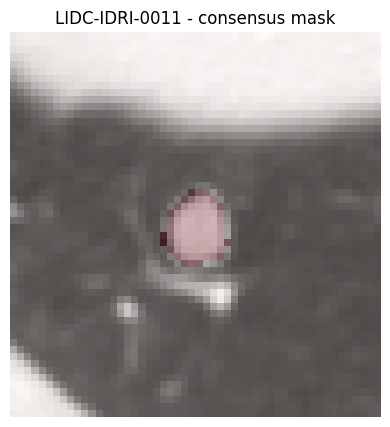

In [ ]:
from pylidc.utils import consensus
import matplotlib.pyplot as plt

anns = nodules[0]

# Generate a consensus mask for the selected nodule annotations.
# clevel=0.5 means a voxel is part of the consensus mask if at least 50% of annotations agree.
# pad: Adds padding around the nodule bounding box for visualization.
cmask, cbbox, masks = consensus(
    anns,
    clevel=0.5,
    pad=[(20, 20), (20, 20), (0, 0)]
)

# Calculate the middle slice index (k) for the z-axis (depth) of the consensus mask
k = cmask.shape[2] // 2

plt.figure(figsize=(5, 5))
# Display the original CT scan slice corresponding to the nodule's bounding box
plt.imshow(vol[cbbox][:, :, k], cmap="gray")
# Overlay the consensus mask on top of the CT slice with transparency
plt.imshow(cmask[:, :, k], alpha=0.3, cmap="Reds")
plt.title(f"{test_pid} - consensus mask")
plt.axis("off")
plt.show()

### Helper functions for CT normalization and patch extraction

Before extracting 2D patches, define small utility functions:

*   normalize_hu – clips Hounsfield Units to a lung window (e.g. −1000 to 400) and rescales to [0, 1]. This standardizes intensity values across scans.
*   crop_patch – given a 2D image, mask, and center location, extracts a fixed‑size square patch (e.g. 128×128), padding with zeros if needed.

These functions centralize basic operations used repeatedly in the main preprocessing loop and keep the loop itself easier to read.

In [ ]:
def normalize_hu(volume, hu_min=-1000, hu_max=400):
    volume = np.clip(volume, hu_min, hu_max)
    volume = (volume - hu_min) / (hu_max - hu_min)
    return volume.astype(np.float32)

def crop_patch(img2d, mask2d, center_x, center_y, patch_size=128):
    half = patch_size // 2

    x1 = max(0, center_x - half)
    x2 = min(img2d.shape[0], center_x + half)
    y1 = max(0, center_y - half)
    y2 = min(img2d.shape[1], center_y + half)

    crop_img = img2d[x1:x2, y1:y2]
    crop_msk = mask2d[x1:x2, y1:y2]

    out_img = np.zeros((patch_size, patch_size), dtype=np.float32)
    out_msk = np.zeros((patch_size, patch_size), dtype=np.uint8)

    out_img[:crop_img.shape[0], :crop_img.shape[1]] = crop_img
    out_msk[:crop_msk.shape[0], :crop_msk.shape[1]] = crop_msk

    return out_img, out_msk

### Main loop: convert LIDC scans into 2D nodule patches

This is the core of the preprocessing notebook. For each selected patient:

1. Load CT volume
2. Cluster nodule annotations
3. Consensus mask per nodule
4. Select representative 2D slice
5. Compute nodule center and crop patch
6. Save patch + metadata

Any patient or nodule that fails at a step (e.g., no nodules, empty masks) is added to a separate error log for later inspection.

In [ ]:
from tqdm import tqdm

meta_rows = []
failed_rows = []

for pid in tqdm(selected_patients):
    try:
        scan = pl.query(pl.Scan).filter(pl.Scan.patient_id == pid).first()

        if scan is None:
            failed_rows.append([pid, "scan not found"])
            continue

        vol = normalize_hu(scan.to_volume())
        nodules = scan.cluster_annotations()

        if len(nodules) == 0:
            failed_rows.append([pid, "no clustered nodules"])
            continue

        for nodule_idx, ann_cluster in enumerate(nodules):
            try:
                cmask, cbbox, masks = consensus(
                    ann_cluster,
                    clevel=0.5,
                    pad=[(20, 20), (20, 20), (0, 0)]
                )

                z_slices = np.where(cmask.sum(axis=(0, 1)) > 0)[0]
                if len(z_slices) == 0:
                    failed_rows.append([pid, f"empty mask nodule {nodule_idx}"])
                    continue

                k = z_slices[len(z_slices) // 2]

                local_img = vol[cbbox][:, :, k]
                local_msk = cmask[:, :, k].astype(np.uint8)

                xs, ys = np.where(local_msk > 0)
                if len(xs) == 0:
                    failed_rows.append([pid, f"no positive pixels nodule {nodule_idx}"])
                    continue

                cx = int(np.mean(xs))
                cy = int(np.mean(ys))

                patch, mpatch = crop_patch(local_img, local_msk, cx, cy, patch_size=128)

                fname = f"{pid}_n{nodule_idx}_z{k}.npy"
                np.save(os.path.join(PATCH_DIR, fname), patch)
                np.save(os.path.join(MASK_DIR, fname), mpatch)

                meta_rows.append({
                    "patient_id": pid,
                    "nodule_id": nodule_idx,
                    "slice_idx": int(k),
                    "patch_file": fname,
                    "mask_file": fname
                })

            except Exception as e:
                failed_rows.append([pid, f"nodule {nodule_idx}: {str(e)}"])

    except Exception as e:
        failed_rows.append([pid, str(e)])

meta_df = pd.DataFrame(meta_rows)
failed_df = pd.DataFrame(failed_rows, columns=["patient_id", "error"])

meta_df.to_csv(os.path.join(PROC_DIR, "patch_meta.csv"), index=False)
failed_df.to_csv(os.path.join(PROC_DIR, "failed_patients.csv"), index=False)

print("Patches created:", len(meta_df))
print("Failed rows:", len(failed_df))
print(meta_df.head())

  0%|          | 0/180 [00:00<?, ?it/s]

Loading dicom files ... This may take a moment.


  1%|          | 1/180 [00:12<37:22, 12.53s/it]

Loading dicom files ... This may take a moment.


  1%|          | 2/180 [00:35<56:14, 18.96s/it]

...

Loading dicom files ... This may take a moment.


 99%|█████████▉| 179/180 [1:12:32<00:33, 33.08s/it]

Loading dicom files ... This may take a moment.


100%|██████████| 180/180 [1:13:02<00:00, 24.35s/it]

Patches created: 502
Failed rows: 22
       patient_id  nodule_id  slice_idx                patch_file  \
0  LIDC-IDRI-0011          0          2  LIDC-IDRI-0011_n0_z2.npy   
1  LIDC-IDRI-0011          1          1  LIDC-IDRI-0011_n1_z1.npy   
2  LIDC-IDRI-0011          2          1  LIDC-IDRI-0011_n2_z1.npy   
3  LIDC-IDRI-0011          3          1  LIDC-IDRI-0011_n3_z1.npy   
4  LIDC-IDRI-0011          4          1  LIDC-IDRI-0011_n4_z1.npy   

                  mask_file  
0  LIDC-IDRI-0011_n0_z2.npy  
1  LIDC-IDRI-0011_n1_z1.npy  
2  LIDC-IDRI-0011_n2_z1.npy  
3  LIDC-IDRI-0011_n3_z1.npy  
4  LIDC-IDRI-0011_n4_z1.npy  


### Sanity checks: visualize a few patches and masks

Before moving on to model training, we visually inspect a few randomly chosen patches to confirm preprocessing worked as expected:

*   Plot the CT patch (grayscale).
*   Plot the binary mask patch.
*   Overlay the mask contour on the CT patch to check alignment.



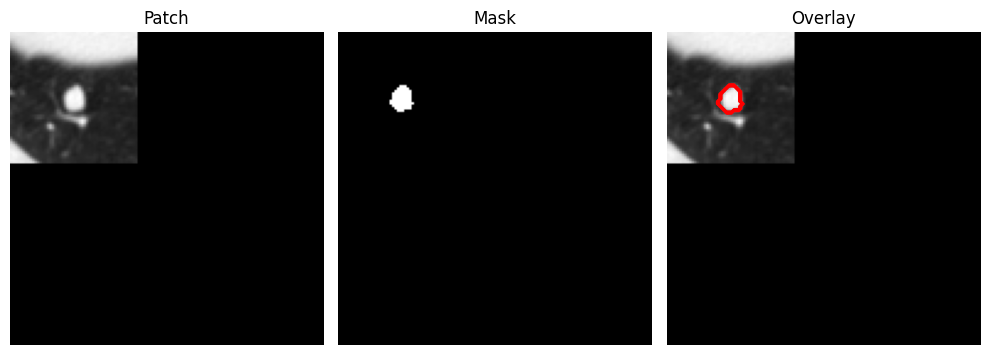

In [ ]:
import matplotlib.pyplot as plt

meta_df = pd.read_csv(os.path.join(PROC_DIR, "patch_meta.csv"))

if len(meta_df) == 0:
    raise RuntimeError("No patches were created. Check failed_patients.csv.")

sample = meta_df.iloc[0]

img = np.load(os.path.join(PATCH_DIR, sample["patch_file"]))
msk = np.load(os.path.join(MASK_DIR, sample["mask_file"]))

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Patch")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(msk, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.contour(msk, colors="r")
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

### Optional: zip processed dataset for training environments

To make it easy to move the processed dataset into Kaggle or other training environments, we compress the output folder into a single ZIP file (e.g. lidc_patches_small.zip).

This ZIP contains:

*   patches/ and masks/ folders
*   patch_meta.csv and failed_patients.csv

The training notebook can then attach this ZIP as a dataset and focus only on modeling, without repeating heavy preprocessing.

In [ ]:
!cd /content/drive/MyDrive/lung_nodule_project && zip -r lidc_patches_small.zip lidc_patches_small

  adding: lidc_patches_small/ (stored 0%)
  adding: lidc_patches_small/patches/ (stored 0%)
  adding: lidc_patches_small/patches/LIDC-IDRI-0011_n0_z2.npy (deflated 90%)
  adding: lidc_patches_small/patches/LIDC-IDRI-0011_n1_z1.npy (deflated 92%)
  adding: lidc_patches_small/patches/LIDC-IDRI-0011_n2_z1.npy (deflated 91%)
  adding: lidc_patches_small/patches/LIDC-IDRI-0011_n3_z1.npy (deflated 92%)
  adding: lidc_patches_small/patches/LIDC-IDRI-0011_n4_z1.npy (deflated 92%)
  adding: lidc_patches_small/patches/LIDC-IDRI-0011_n5_z1.npy (deflated 92%)
  adding: lidc_patches_small/patches/LIDC-IDRI-0011_n6_z1.npy (deflated 91%)
  adding: lidc_patches_small/patches/LIDC-IDRI-0011_n7_z2.npy (deflated 92%)
  adding: lidc_patches_small/patches/LIDC-IDRI-0011_n8_z1.npy (deflated 91%)
  adding: lidc_patches_small/patches/LIDC-IDRI-0011_n9_z3.npy (deflated 87%)
  adding: lidc_patches_small/patches/LIDC-IDRI-0024_n0_z1.npy (deflated 91%)
  adding: lidc_patches_small/patches/LIDC-IDRI-0024_n1_z2.npy